In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.preprocessing import LabelEncoder

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
PROJECT_PATH = r"C:\Users\abc\projects\Cancer Cell Classification Project"

DATA_DIR = os.path.join(PROJECT_PATH, "Data")
FIGURES_DIR = os.path.join(PROJECT_PATH, "Figures")
NOTEBOOKS_DIR = os.path.join(PROJECT_PATH, "Notebooks")

os.makedirs(FIGURES_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)

DATA_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Data
FIGURES_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Figures
NOTEBOOKS_DIR: C:\Users\abc\projects\Cancer Cell Classification Project\Notebooks


In [5]:
X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (158, 128, 128, 3)
y_test shape: (158,)


In [7]:
df = pd.read_csv(os.path.join(DATA_DIR, "expanded_dataset.csv"))

encoder = LabelEncoder()
encoder.fit(df["moa"])

class_names = list(encoder.classes_)
num_classes = len(class_names)

print("Encoded class order:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Encoded class order:
0: Aurora kinase inhibitors
1: DNA damage
2: Eg5 inhibitors
3: Microtubule destabilizers
4: Microtubule stabilizers


In [9]:
best_model_path = os.path.join(NOTEBOOKS_DIR, "best_resnet50_transfer_model.keras")
model = load_model(best_model_path)

print("Best ResNet50 model loaded successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Best ResNet50 model loaded successfully.
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 5)


In [13]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.output.shape)
    last_conv_layer_name = "conv5_block3_out"
print("Selected Grad-CAM target layer:", last_conv_layer_name)

0 input_layer (None, 128, 128, 3)
1 conv1_pad (None, 134, 134, 3)
2 conv1_conv (None, 64, 64, 64)
3 conv1_bn (None, 64, 64, 64)
4 conv1_relu (None, 64, 64, 64)
5 pool1_pad (None, 66, 66, 64)
6 pool1_pool (None, 32, 32, 64)
7 conv2_block1_1_conv (None, 32, 32, 64)
8 conv2_block1_1_bn (None, 32, 32, 64)
9 conv2_block1_1_relu (None, 32, 32, 64)
10 conv2_block1_2_conv (None, 32, 32, 64)
11 conv2_block1_2_bn (None, 32, 32, 64)
12 conv2_block1_2_relu (None, 32, 32, 64)
13 conv2_block1_0_conv (None, 32, 32, 256)
14 conv2_block1_3_conv (None, 32, 32, 256)
15 conv2_block1_0_bn (None, 32, 32, 256)
16 conv2_block1_3_bn (None, 32, 32, 256)
17 conv2_block1_add (None, 32, 32, 256)
18 conv2_block1_out (None, 32, 32, 256)
19 conv2_block2_1_conv (None, 32, 32, 64)
20 conv2_block2_1_bn (None, 32, 32, 64)
21 conv2_block2_1_relu (None, 32, 32, 64)
22 conv2_block2_2_conv (None, 32, 32, 64)
23 conv2_block2_2_bn (None, 32, 32, 64)
24 conv2_block2_2_relu (None, 32, 32, 64)
25 conv2_block2_3_conv (None, 32, 32

In [15]:
X_test_resnet = preprocess_input(X_test * 255.0)

print("ResNet preprocessing complete.")
print("X_test_resnet shape:", X_test_resnet.shape)

ResNet preprocessing complete.
X_test_resnet shape: (158, 128, 128, 3)


In [17]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a single input image.
    
    Parameters:
        img_array: preprocessed image array of shape (1, H, W, C)
        model: trained Keras model
        last_conv_layer_name: name of the last convolutional layer
        pred_index: optional class index to explain; if None, uses predicted class
    
    Returns:
        heatmap: 2D NumPy array normalized to [0, 1]
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [19]:
def overlay_gradcam_on_image(original_img, heatmap, alpha=0.4):
    """
    Overlays a Grad-CAM heatmap on the original image.
    
    Parameters:
        original_img: original image in [0,1], shape (H, W, C)
        heatmap: 2D heatmap in [0,1]
        alpha: transparency factor
    
    Returns:
        superimposed_img: RGB image array in [0,1]
    """
    heatmap = np.uint8(255 * heatmap)

    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = Image.fromarray(np.uint8(jet_heatmap * 255))
    jet_heatmap = jet_heatmap.resize((original_img.shape[1], original_img.shape[0]))
    jet_heatmap = np.array(jet_heatmap) / 255.0

    superimposed_img = jet_heatmap * alpha + original_img
    superimposed_img = np.clip(superimposed_img, 0, 1)

    return superimposed_img

C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\abc\AppData\Local\Temp\ipykernel_10464\109149164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


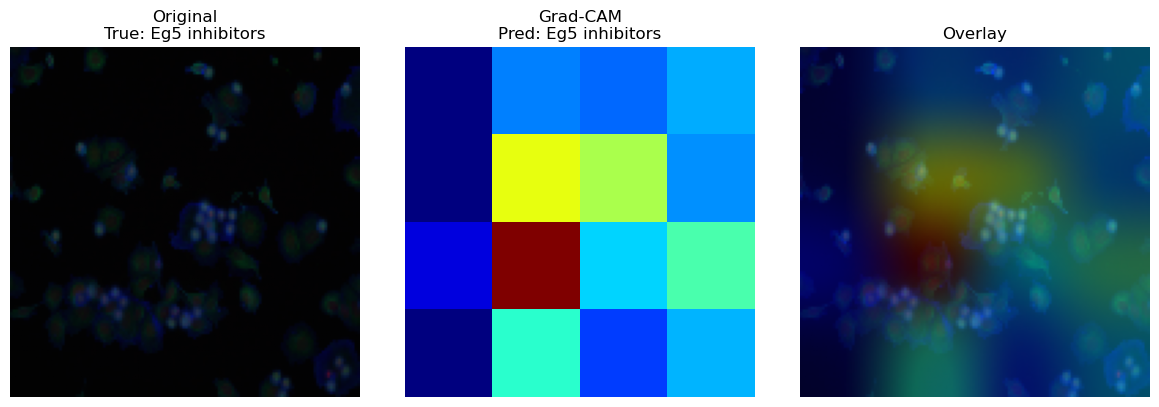

In [21]:
sample_idx = 0

original_img = X_test[sample_idx]
input_img = np.expand_dims(X_test_resnet[sample_idx], axis=0)

pred_probs = model.predict(input_img, verbose=0)
pred_class = np.argmax(pred_probs[0])
true_class = y_test[sample_idx]

heatmap = make_gradcam_heatmap(
    img_array=input_img,
    model=model,
    last_conv_layer_name=last_conv_layer_name
)

overlay_img = overlay_gradcam_on_image(original_img, heatmap, alpha=0.4)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(f"Original\nTrue: {class_names[true_class]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title(f"Grad-CAM\nPred: {class_names[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\abc\AppData\Local\Temp\ipykernel_10464\109149164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


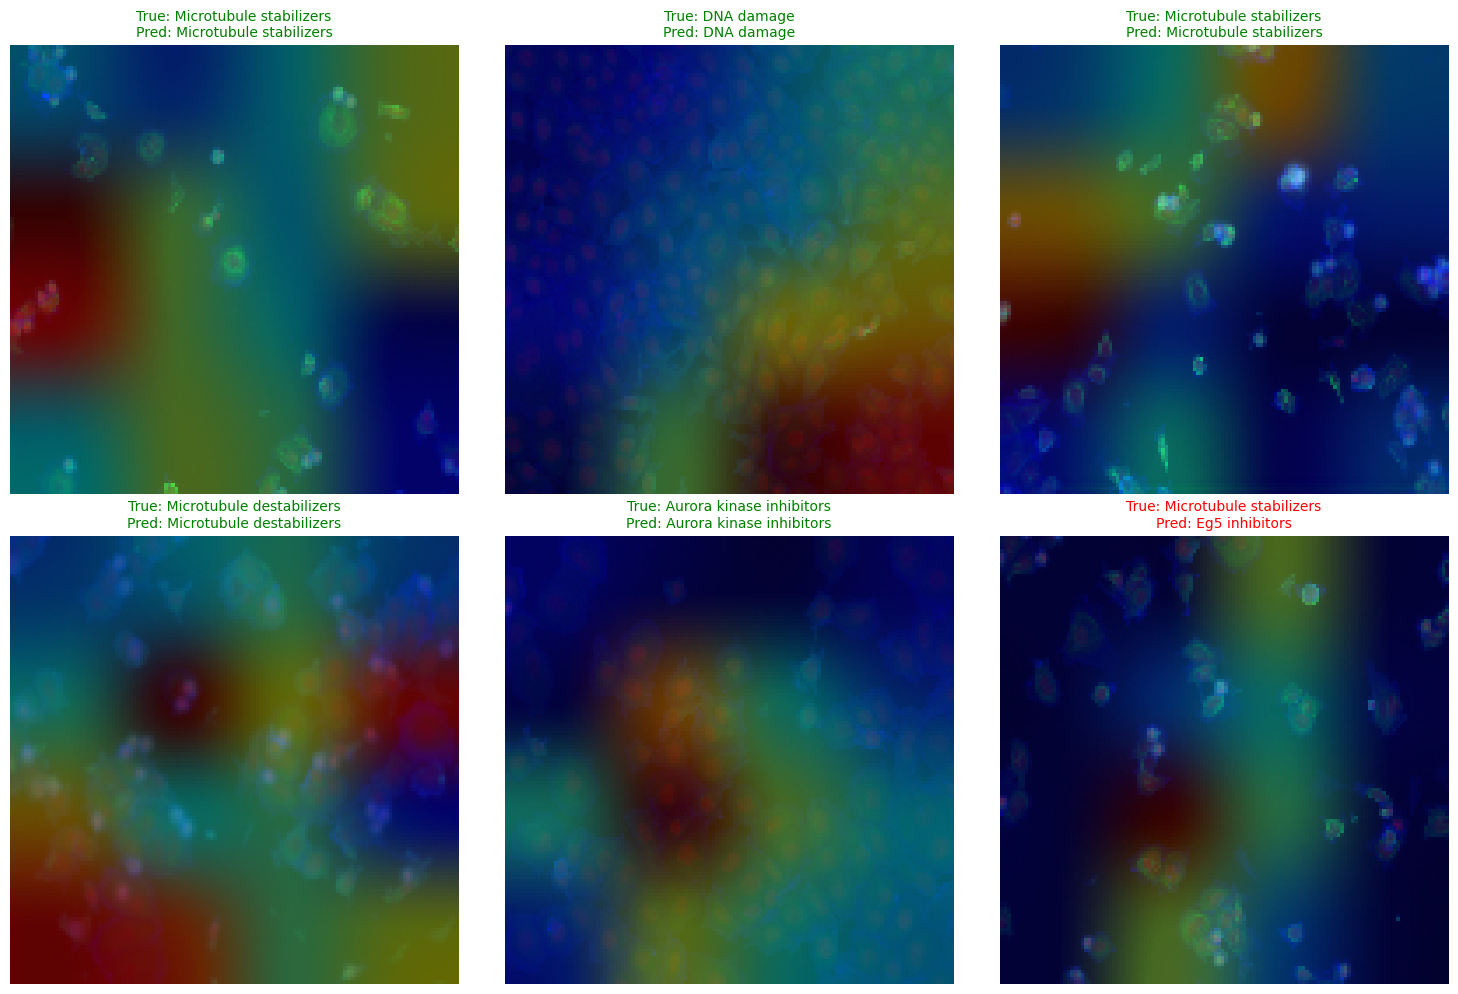

Random Grad-CAM figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_gradcam_random_samples.png


In [23]:
num_samples = 6
indices = random.sample(range(len(X_test)), num_samples)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    original_img = X_test[idx]
    input_img = np.expand_dims(X_test_resnet[idx], axis=0)

    pred_probs = model.predict(input_img, verbose=0)
    pred_class = np.argmax(pred_probs[0])
    true_class = y_test[idx]

    heatmap = make_gradcam_heatmap(
        img_array=input_img,
        model=model,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay_img = overlay_gradcam_on_image(original_img, heatmap, alpha=0.4)

    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay_img)
    plt.title(
        f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}",
        color="green" if true_class == pred_class else "red",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()

gradcam_random_path = os.path.join(FIGURES_DIR, "resnet50_gradcam_random_samples.png")
plt.savefig(gradcam_random_path, dpi=300, bbox_inches="tight")
plt.show()

print("Random Grad-CAM figure saved to:", gradcam_random_path)

Number of correctly classified test samples: 138


C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\abc\AppData\Local\Temp\ipykernel_10464\109149164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


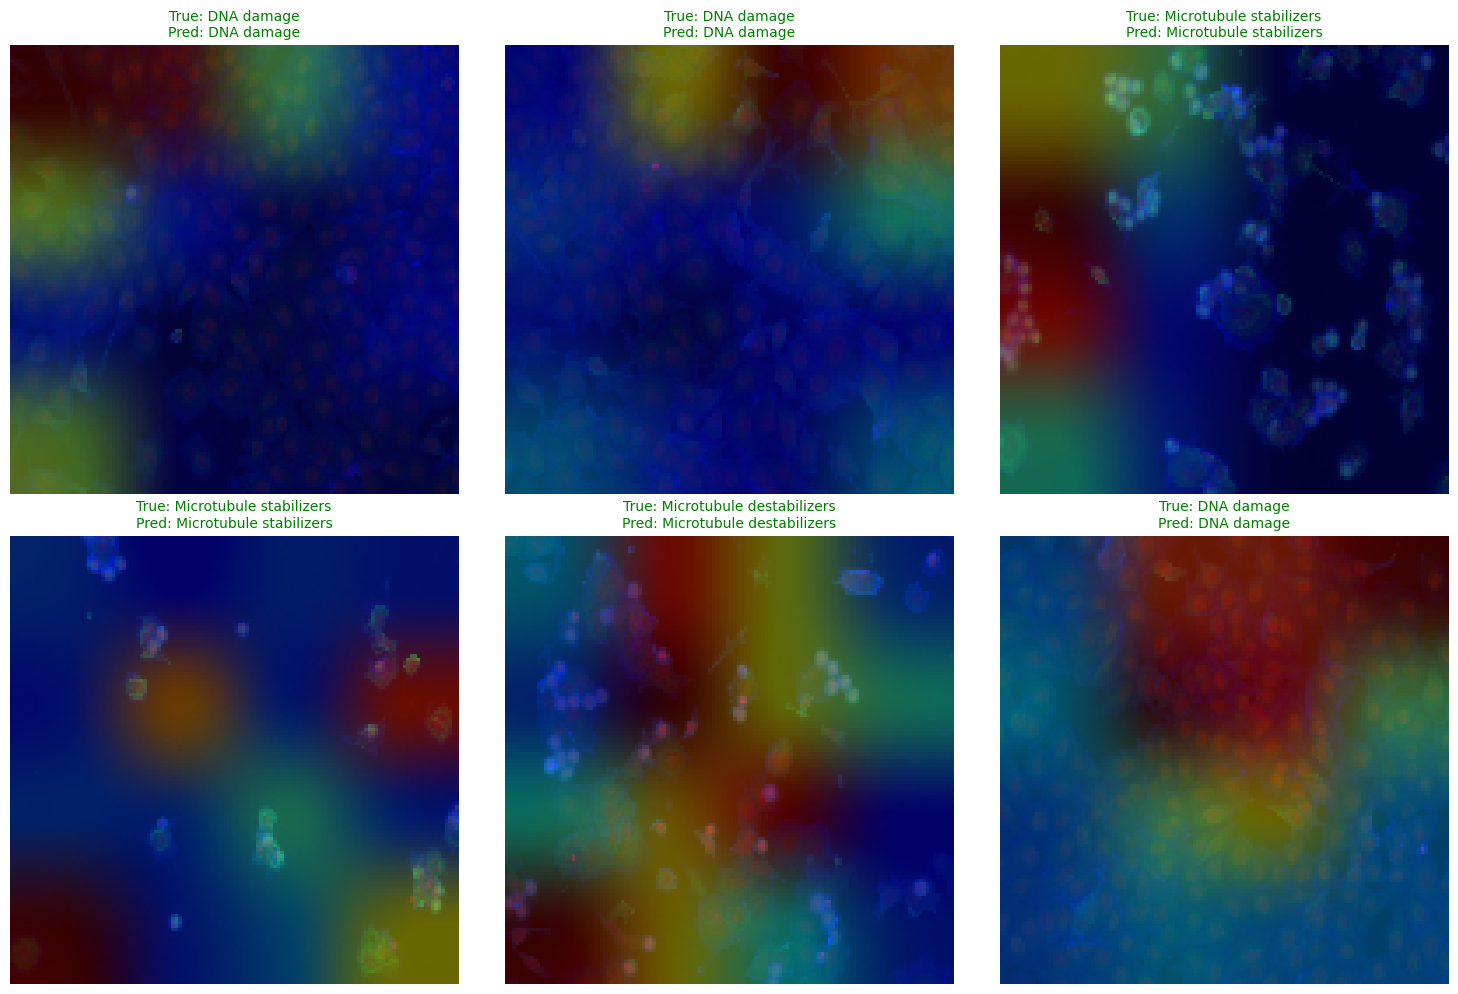

Correct-sample Grad-CAM figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_gradcam_correct_samples.png


In [25]:
# Predict all test labels first
y_pred_probs = model.predict(X_test_resnet, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

correct_indices = np.where(y_pred == y_test)[0]
print("Number of correctly classified test samples:", len(correct_indices))

num_samples = min(6, len(correct_indices))
selected_indices = random.sample(list(correct_indices), num_samples)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(selected_indices):
    original_img = X_test[idx]
    input_img = np.expand_dims(X_test_resnet[idx], axis=0)

    pred_probs = model.predict(input_img, verbose=0)
    pred_class = np.argmax(pred_probs[0])
    true_class = y_test[idx]

    heatmap = make_gradcam_heatmap(
        img_array=input_img,
        model=model,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay_img = overlay_gradcam_on_image(original_img, heatmap, alpha=0.4)

    plt.subplot(2, 3, i + 1)
    plt.imshow(overlay_img)
    plt.title(
        f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}",
        color="green",
        fontsize=10
    )
    plt.axis("off")

plt.tight_layout()

gradcam_correct_path = os.path.join(FIGURES_DIR, "resnet50_gradcam_correct_samples.png")
plt.savefig(gradcam_correct_path, dpi=300, bbox_inches="tight")
plt.show()

print("Correct-sample Grad-CAM figure saved to:", gradcam_correct_path)

Number of misclassified test samples: 20


C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\abc\AppData\Local\Temp\ipykernel_10464\109149164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


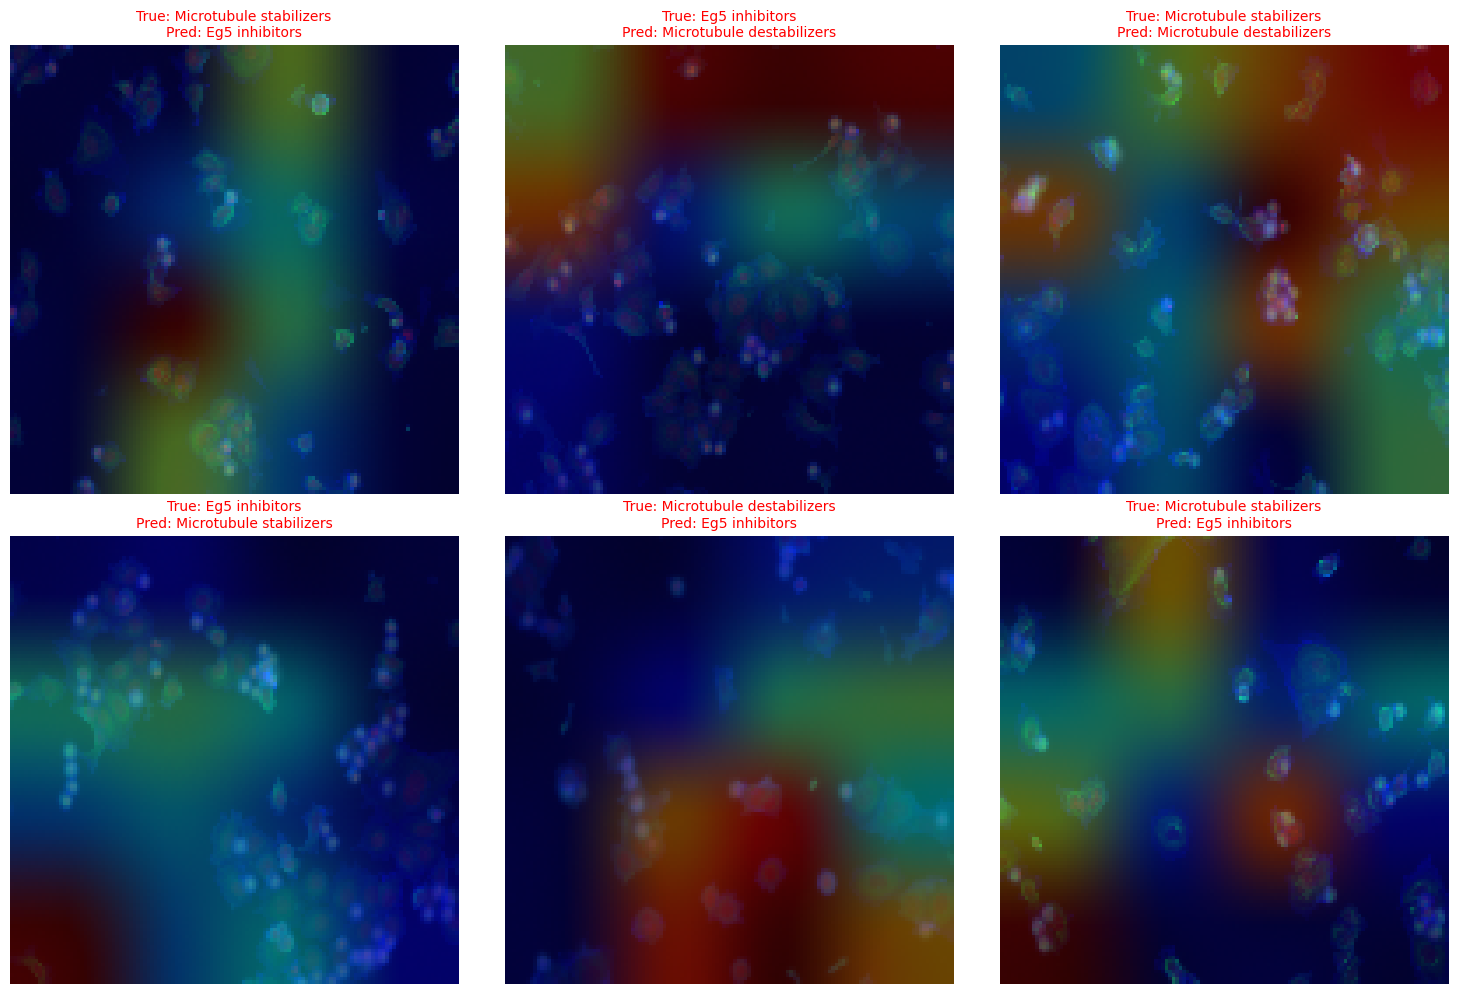

Misclassified-sample Grad-CAM figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_gradcam_misclassified_samples.png


In [27]:
misclassified_indices = np.where(y_pred != y_test)[0]
print("Number of misclassified test samples:", len(misclassified_indices))

if len(misclassified_indices) > 0:
    num_samples = min(6, len(misclassified_indices))
    selected_indices = random.sample(list(misclassified_indices), num_samples)

    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(selected_indices):
        original_img = X_test[idx]
        input_img = np.expand_dims(X_test_resnet[idx], axis=0)

        pred_probs = model.predict(input_img, verbose=0)
        pred_class = np.argmax(pred_probs[0])
        true_class = y_test[idx]

        heatmap = make_gradcam_heatmap(
            img_array=input_img,
            model=model,
            last_conv_layer_name=last_conv_layer_name
        )

        overlay_img = overlay_gradcam_on_image(original_img, heatmap, alpha=0.4)

        plt.subplot(2, 3, i + 1)
        plt.imshow(overlay_img)
        plt.title(
            f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}",
            color="red",
            fontsize=10
        )
        plt.axis("off")

    plt.tight_layout()

    gradcam_misclassified_path = os.path.join(FIGURES_DIR, "resnet50_gradcam_misclassified_samples.png")
    plt.savefig(gradcam_misclassified_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Misclassified-sample Grad-CAM figure saved to:", gradcam_misclassified_path)
else:
    print("No misclassified samples found.")

C:\Users\abc\anaconda\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\abc\AppData\Local\Temp\ipykernel_10464\109149164.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


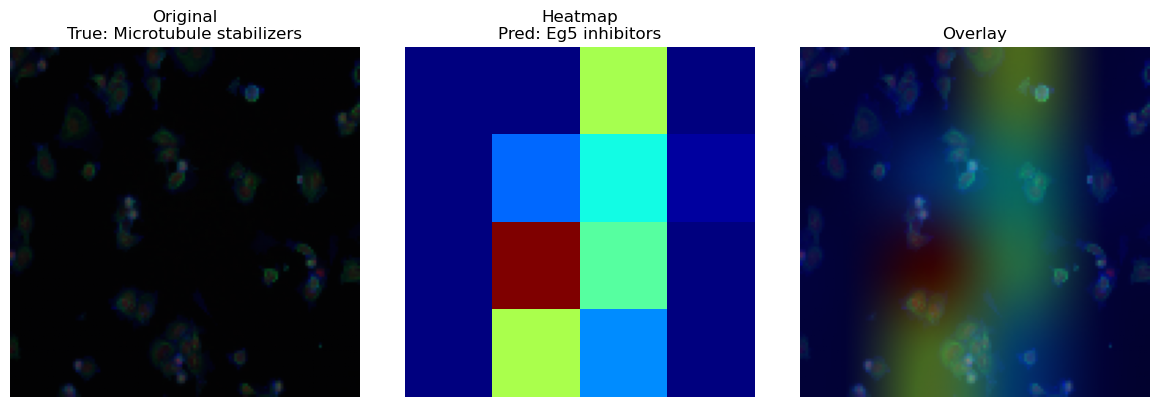

Single Grad-CAM example saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_gradcam_single_example.png


In [29]:
report_idx = selected_indices[0] if len(correct_indices) > 0 else 0

original_img = X_test[report_idx]
input_img = np.expand_dims(X_test_resnet[report_idx], axis=0)

pred_probs = model.predict(input_img, verbose=0)
pred_class = np.argmax(pred_probs[0])
true_class = y_test[report_idx]

heatmap = make_gradcam_heatmap(
    img_array=input_img,
    model=model,
    last_conv_layer_name=last_conv_layer_name
)

overlay_img = overlay_gradcam_on_image(original_img, heatmap, alpha=0.4)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title(f"Original\nTrue: {class_names[true_class]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title(f"Heatmap\nPred: {class_names[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()

single_gradcam_path = os.path.join(FIGURES_DIR, "resnet50_gradcam_single_example.png")
plt.savefig(single_gradcam_path, dpi=300, bbox_inches="tight")
plt.show()

print("Single Grad-CAM example saved to:", single_gradcam_path)

In [31]:
gradcam_summary_path = os.path.join(FIGURES_DIR, "resnet50_gradcam_summary.txt")

with open(gradcam_summary_path, "w", encoding="utf-8") as f:
    f.write("ResNet50 Grad-CAM Summary\n")
    f.write("=========================\n\n")
    f.write(f"Grad-CAM target layer: {last_conv_layer_name}\n")
    f.write(f"Number of test samples: {len(X_test)}\n")
    f.write(f"Correctly classified samples: {len(correct_indices)}\n")
    f.write(f"Misclassified samples: {len(misclassified_indices)}\n\n")
    f.write("Saved figures:\n")
    f.write("- resnet50_gradcam_random_samples.png\n")
    f.write("- resnet50_gradcam_correct_samples.png\n")
    f.write("- resnet50_gradcam_misclassified_samples.png\n")
    f.write("- resnet50_gradcam_single_example.png\n")

print("Grad-CAM summary saved to:", gradcam_summary_path)

Grad-CAM summary saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\resnet50_gradcam_summary.txt
